In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
# 1. Load dữ liệu
df = pd.read_csv('../../data/processed/training_change_final.csv', parse_dates=['Datetime'], index_col='Datetime')

In [13]:
# 2. FEATURE ENGINEERING (Tạo Lag - Độ trễ)
# Mục tiêu: Dùng giá của phút trước (t-1) để dự đoán giá phút này (t)
features = ['Gold', 'Brent', 'Silver', 'Wheat', 'USD index']
target = 'Gold'

# Tạo cột lag1 (dịch xuống 1 dòng) cho tất cả các yếu tố
for col in features:
    df[f'{col}_lag1'] = df[col].shift(1)

# Xóa dòng đầu tiên bị NaN do shift
df.dropna(inplace=True)

In [14]:
# 3. CHUẨN BỊ DỮ LIỆU TRAIN/TEST
# Input (X): Các cột Lag (Dữ liệu quá khứ)
X = df[[f'{col}_lag1' for col in features]]
# Output (y): Giá Gold hiện tại
y = df[target]

# Chia dữ liệu: 80% đầu để học, 20% sau để test
# LƯU Ý: Không dùng train_test_split(shuffle=True) vì làm mất tính thời gian
split_point = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

In [15]:
# 4. HUẤN LUYỆN MÔ HÌNH
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
# 5. DỰ ĐOÁN & ĐÁNH GIÁ
predictions = model.predict(X_test)

# In các chỉ số
print(f"MSE (Sai số bình phương trung bình): {mean_squared_error(y_test, predictions):.4f}")
print(f"R2 Score (Độ phù hợp): {r2_score(y_test, predictions):.4f}")

# Xem trọng số (Yếu tố nào ảnh hưởng mạnh nhất?)
print("\n--- Trọng số (Coefficients) ---")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}_lag1: {coef:.4f}")

MSE (Sai số bình phương trung bình): 0.0000
R2 Score (Độ phù hợp): 0.9939

--- Trọng số (Coefficients) ---
Gold_lag1: 0.9981
Brent_lag1: 0.0003
Silver_lag1: 0.0005
Wheat_lag1: 0.0000
USD index_lag1: 0.0014


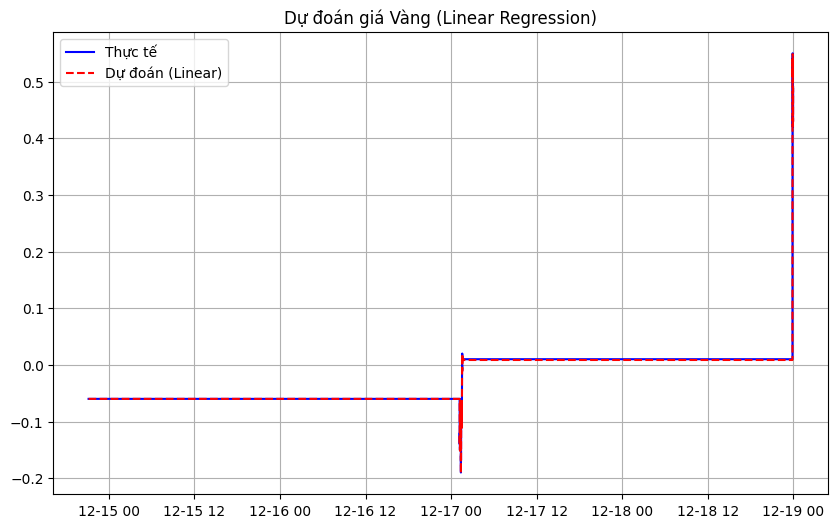

In [17]:
# 6. VẼ BIỂU ĐỒ
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test.values, label='Thực tế', color='blue')
plt.plot(y_test.index, predictions, label='Dự đoán (Linear)', color='red', linestyle='--')
plt.title('Dự đoán giá Vàng (Linear Regression)')
plt.legend()
plt.grid(True)
plt.show()


=== MỨC ĐỘ ẢNH HƯỞNG CỦA CÁC YẾU TỐ (TỪ MẠNH → YẾU) ===
           Yeu_to     He_so  Do_anh_huong
0       Gold_lag1  0.998148      0.998148
4  USD index_lag1  0.001444      0.001444
2     Silver_lag1  0.000477      0.000477
1      Brent_lag1  0.000272      0.000272
3      Wheat_lag1  0.000037      0.000037


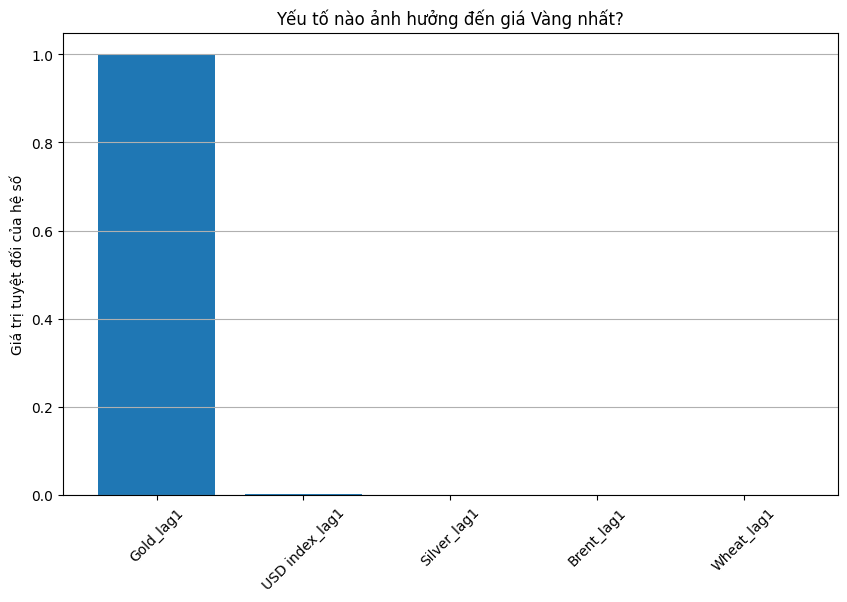

In [18]:
# 7. XEM YẾU TỐ NÀO ẢNH HƯỞNG MẠNH NHẤT?

# Tạo bảng lưu hệ số và tên yếu tố
bang_anh_huong = pd.DataFrame({
    'Yeu_to': [f'{col}_lag1' for col in features],
    'He_so': model.coef_
})

# Lấy giá trị tuyệt đối để đo mức độ ảnh hưởng
bang_anh_huong['Do_anh_huong'] = bang_anh_huong['He_so'].abs()

# Sắp xếp từ ảnh hưởng mạnh nhất đến yếu nhất
bang_anh_huong = bang_anh_huong.sort_values(by='Do_anh_huong', ascending=False)

print("\n=== MỨC ĐỘ ẢNH HƯỞNG CỦA CÁC YẾU TỐ (TỪ MẠNH → YẾU) ===")
print(bang_anh_huong)

# Vẽ biểu đồ mức độ ảnh hưởng
plt.figure(figsize=(10, 6))
plt.bar(bang_anh_huong['Yeu_to'], bang_anh_huong['Do_anh_huong'])
plt.title('Yếu tố nào ảnh hưởng đến giá Vàng nhất?')
plt.ylabel('Giá trị tuyệt đối của hệ số')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os

# 1. Load data gốc (để lấy thông tin min/max của giá Vàng thật)
# Bạn sửa lại đường dẫn đúng tới file data sạch của bạn
path_data = '../../data/raw/data_price_realtime.csv' # Hoặc file data_final của bạn
df_raw = pd.read_csv(path_data, parse_dates=['Datetime'], index_col='Datetime')

# 2. Tạo một Scaler riêng chỉ cho cột Gold (Target)
# Việc này giúp việc inverse_transform không bị lỗi kích thước
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(df_raw[['Gold']]) # Học min/max của cột Gold

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [20]:
# 3. Đảo ngược chuẩn hóa (Đưa về giá USD)
# reshape(-1, 1) giúp biến mảng 1 chiều thành cột dọc để scaler hiểu
pred_usd = target_scaler.inverse_transform(predictions.reshape(-1, 1))
actual_usd = target_scaler.inverse_transform(y_test.values.reshape(-1, 1))

# 4. Tạo DataFrame kết quả
# Lưu ý: y_test.index chính là thời gian thực của tập test
result_df = pd.DataFrame({
    'Datetime': y_test.index,
    'Actual': actual_usd.flatten(),      # Giá thực (USD)
    'Predicted': pred_usd.flatten()      # Giá dự báo (USD)
})

# 5. Lưu ra file CSV (Nhớ thay đổi tên file cho đúng model: xgb, rf, linear, lgbm...)
save_path = '../../results/predictions/LN.csv' # <--- SỬA TÊN FILE Ở ĐÂY
os.makedirs(os.path.dirname(save_path), exist_ok=True)
result_df.to_csv(save_path, index=False)

print(f"✅ Đã lưu kết quả (USD) vào: {save_path}")
print(result_df.head())

✅ Đã lưu kết quả (USD) vào: ../../results/predictions/LN.csv
             Datetime     Actual    Predicted
0 2025-12-14 21:09:00  4147.9562  4147.955818
1 2025-12-14 21:09:10  4147.9562  4147.955818
2 2025-12-14 21:09:20  4147.9562  4147.955818
3 2025-12-14 21:09:30  4147.9562  4147.955818
4 2025-12-14 21:09:40  4147.9562  4147.955818
